In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('googleplaystore.csv')
df.drop_duplicates(inplace=True)
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


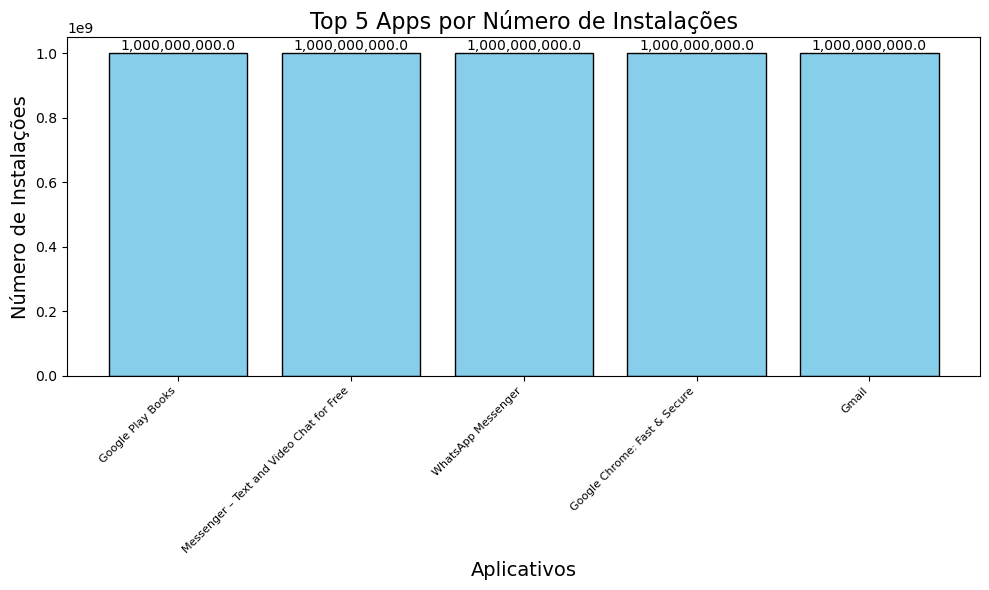

In [3]:
# Grafico Top 5

df['Installs'] = df['Installs'].astype(str)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False).str.replace('+', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

top_5_installs = df.nlargest(5, 'Installs')

plt.figure(figsize=(10, 6))
plt.bar(top_5_installs['App'], top_5_installs['Installs'], color='skyblue', edgecolor='black')
plt.xlabel('Aplicativos', fontsize=14)
plt.ylabel('Número de Instalações', fontsize=14)
plt.title('Top 5 Apps por Número de Instalações', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=8)
for i, v in enumerate(top_5_installs['Installs']):
    plt.text(i, v + 0.05, f'{v:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

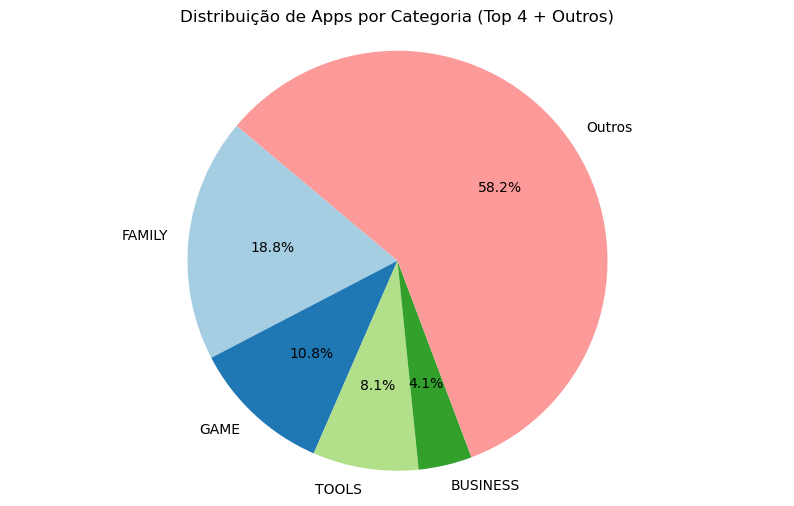

In [4]:
# Grafico Pizza

category_counts = df['Category'].value_counts()


top_4_categories = category_counts.head(4)


other_categories = category_counts.iloc[4:].sum()


categories_to_plot = pd.concat([top_4_categories, pd.Series({'Outros': other_categories})])


plt.figure(figsize=(10, 6))
plt.pie(categories_to_plot, labels=categories_to_plot.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribuição de Apps por Categoria (Top 4 + Outros)')
plt.axis('equal')  # Garantir que o gráfico seja um círculo
plt.show()

O app mais caro é: App               I'm Rich - Trump Edition
Category                         LIFESTYLE
Rating                                 3.6
Reviews                              275.0
Size                                  7.3M
Installs                           10000.0
Type                                  Paid
Price                                400.0
Content Rating                    Everyone
Genres                           Lifestyle
Last Updated                   May 3, 2018
Current Ver                          1.0.1
Android Ver                     4.1 and up
Name: 4367, dtype: object


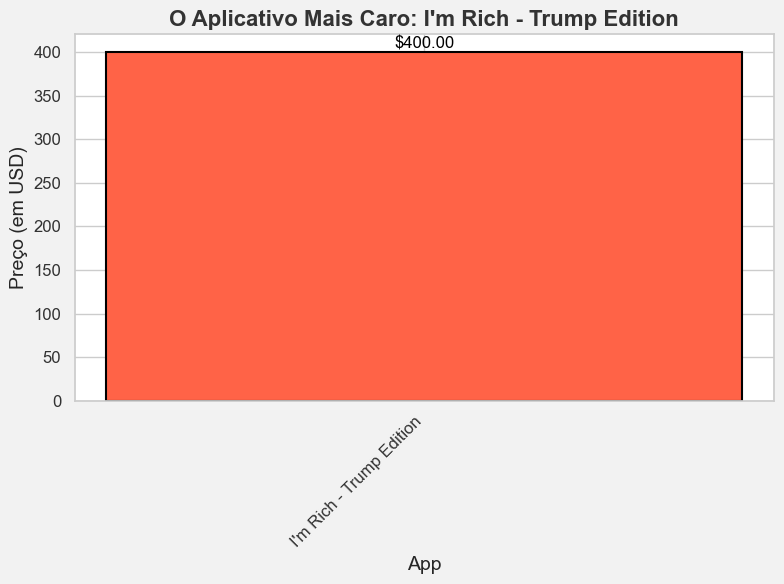

In [14]:
df['Price'] = df['Price'].replace({'\\$': '', ',': ''}, regex=True)
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


df_filtered = df[df['Price'] > 0.0]


if not df_filtered.empty:
    most_expensive_app = df_filtered.loc[df_filtered['Price'].idxmax()]


    print("O app mais caro é:", most_expensive_app)


    plt.figure(figsize=(8, 6))


    bars = plt.bar(most_expensive_app['App'], most_expensive_app['Price'], color='#FF6347', edgecolor='black', linewidth=1.5)


    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'${yval:,.2f}', ha='center', va='bottom', fontsize=12, color='black')

 
    plt.title(f'O Aplicativo Mais Caro: {most_expensive_app["App"]}', fontsize=16, weight='bold', color='#333333')
    plt.xlabel('App', fontsize=14)
    plt.ylabel('Preço (em USD)', fontsize=14)


    plt.xticks(fontsize=12, rotation=45, ha='right', color='#333333')
    plt.yticks(fontsize=12, color='#333333')


    plt.gcf().set_facecolor('#f2f2f2')


    plt.tight_layout()


    plt.show()
else:
    print("Não há aplicativos com preços válidos.")


Quantidade de aplicativos classificados como 'Mature 17+': 447



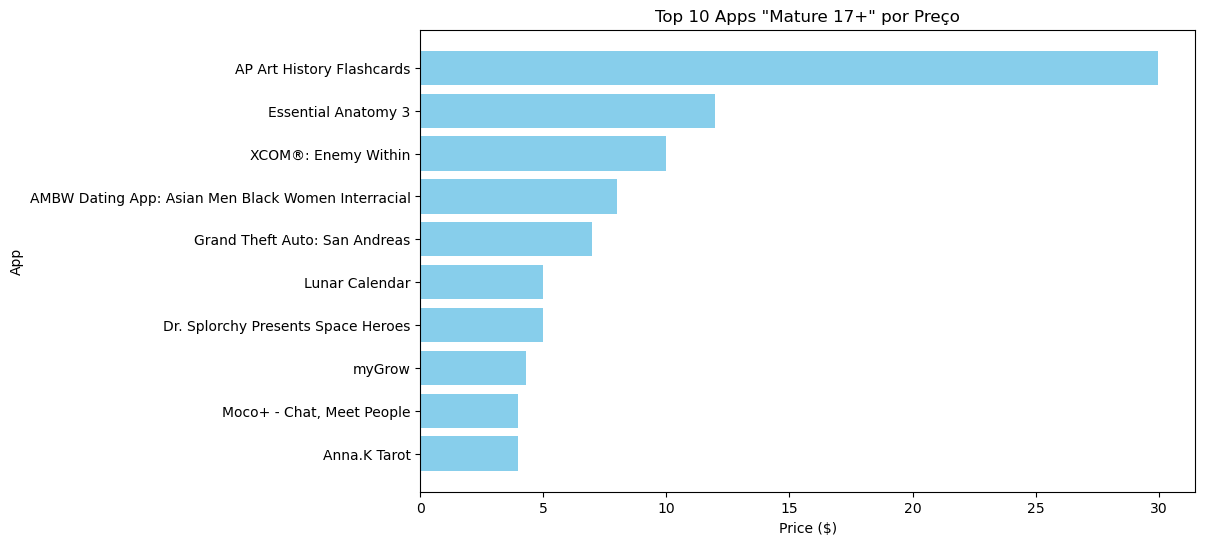

In [6]:
mature_apps = df[df['Content Rating'] == 'Mature 17+']

mature_apps_count = mature_apps.shape[0]

if mature_apps_count > 0:
    print(f"\nQuantidade de aplicativos classificados como 'Mature 17+': {mature_apps_count}\n")
    

    mature_apps.loc[:, 'Price'] = mature_apps['Price'].replace({'\\$': '', ',': ''}, regex=True)
    mature_apps.loc[:, 'Price'] = pd.to_numeric(mature_apps['Price'], errors='coerce')
    

    mature_apps_sorted = mature_apps.sort_values(by='Price', ascending=False)


    top_10_mature_apps = mature_apps_sorted.head(10)
    

    plt.figure(figsize=(10, 6))
    plt.barh(top_10_mature_apps['App'], top_10_mature_apps['Price'], color='skyblue')
    plt.xlabel('Price ($)')
    plt.ylabel('App')
    plt.title('Top 10 Apps "Mature 17+" por Preço')
    plt.gca().invert_yaxis()  
    plt.show()
else:
    print("Nenhum aplicativo classificado como 'Mature 17+' encontrado.")

                                                    App   Reviews
4328                                           Facebook  78158306
9042                                 WhatsApp Messenger  69119316
5399                                          Instagram  66577446
6166           Messenger – Text and Video Chat for Free  56646578
2564                                     Clash of Clans  44893888
2573            Clean Master- Space Cleaner & Antivirus  42916526
8080                                     Subway Surfers  27725352
9226                                            YouTube  25655305
7722  Security Master - Antivirus, VPN, AppLock, Boo...  24900999
2561                                       Clash Royale  23136735


<Figure size 1000x600 with 0 Axes>

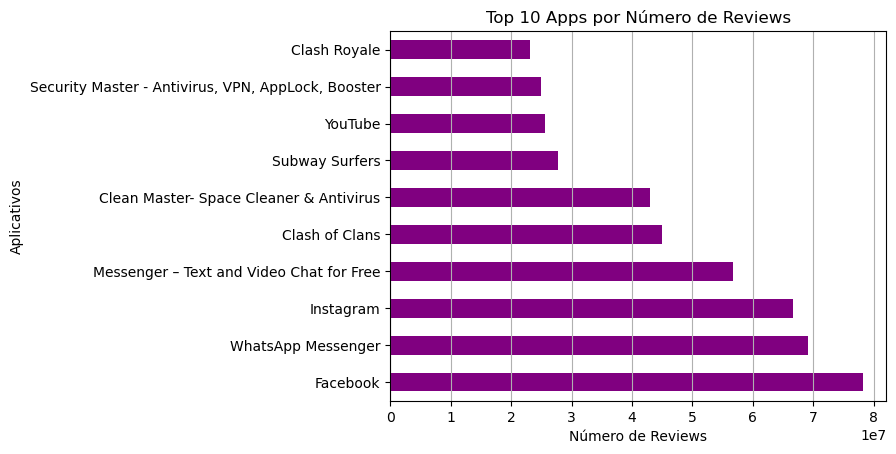

In [7]:
def convert_reviews(value):
    if isinstance(value, str):
        if 'M' in value:
            return float(value.replace('M', '').strip()) * 1_000_000
        elif 'K' in value:
            return float(value.replace('K', '').strip()) * 1_000
    return pd.to_numeric(value, errors='coerce')


df['Reviews'] = df['Reviews'].apply(convert_reviews)

df_top_reviews = df.groupby('App')['Reviews'].max().reset_index()


top_10_reviews = df_top_reviews.sort_values(by='Reviews', ascending=False).head(10)


top_10_reviews['Reviews'] = top_10_reviews['Reviews'].astype(int)


print(top_10_reviews)


plt.figure(figsize=(10,6))
top_10_reviews.plot(kind='barh', x='App', y='Reviews', color='purple', legend=False)
plt.title('Top 10 Apps por Número de Reviews')
plt.xlabel('Número de Reviews')
plt.ylabel('Aplicativos')
plt.grid(True, axis='x')
plt.show()

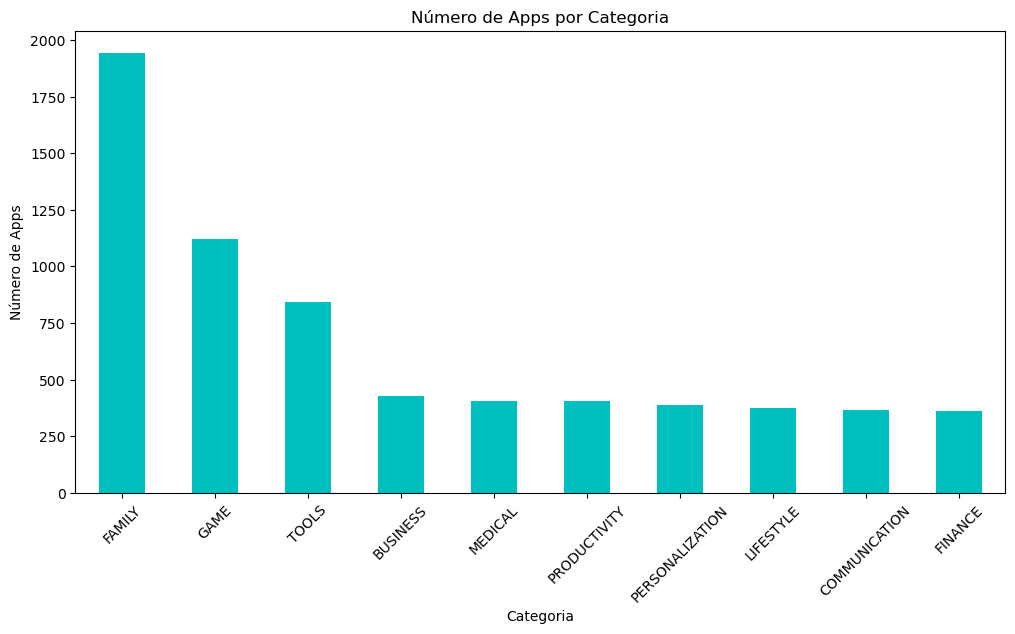

In [8]:
category_counts = df['Category'].value_counts()


plt.figure(figsize=(12,6))
category_counts.head(10).plot(kind='bar', color='c')
plt.title('Número de Apps por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Número de Apps')
plt.xticks(rotation=45)
plt.show()